<a href="https://colab.research.google.com/github/melia1702/Pertemuan-keempat/blob/main/Latihan_1_Pertemuan_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload gambar grayscale atau RGB


Saving WhatsApp Image 2026-03-10 at 09.22.22.jpeg to WhatsApp Image 2026-03-10 at 09.22.22.jpeg


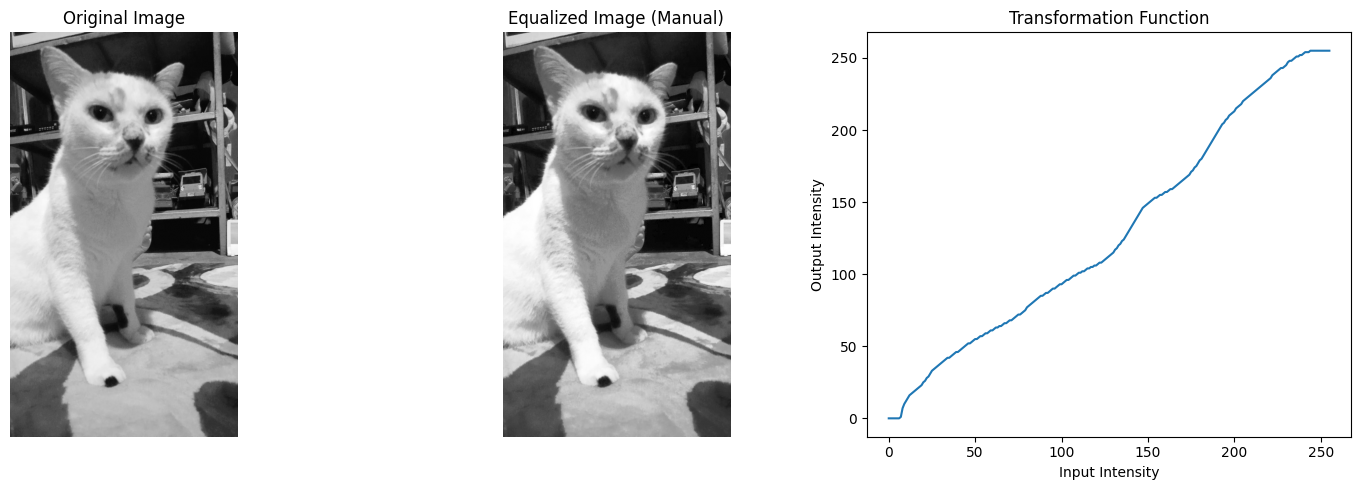

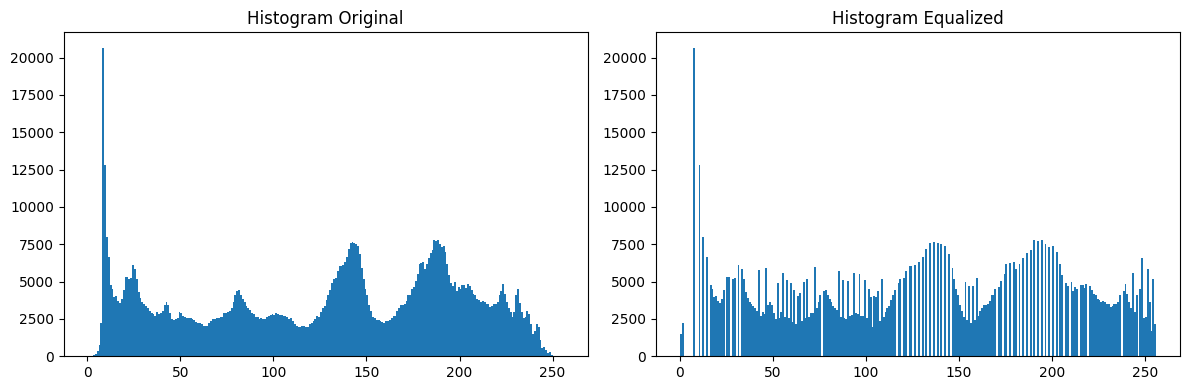

In [ ]:
# ============================================
# MANUAL HISTOGRAM EQUALIZATION (TANPA OPENCV)
# ============================================

from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ============================================
# 1. Upload Gambar
# ============================================

print("Upload gambar grayscale atau RGB")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Baca gambar
img = cv2.imread(image_path)

# Jika RGB → ubah ke grayscale
if len(img.shape) == 3:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ============================================
# 2. Fungsi Manual Histogram Equalization
# ============================================

def manual_histogram_equalization(image):
    """
    Manual implementation of histogram equalization

    Parameters:
    image: Input grayscale image (0-255)

    Returns:
    Equalized image and transformation function
    """

    # 1. Hitung histogram manual
    histogram = np.zeros(256)

    for pixel in image.flatten():
        histogram[pixel] += 1

    # 2. Hitung cumulative histogram (CDF)
    cdf = np.zeros(256)
    cdf[0] = histogram[0]

    for i in range(1, 256):
        cdf[i] = cdf[i-1] + histogram[i]

    # Normalisasi CDF
    cdf_normalized = cdf / cdf[-1]  # bagi total pixel

    # 3. Hitung transformation function
    transformation = np.round(cdf_normalized * 255)

    # 4. Apply transformation
    equalized_image = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            equalized_image[i, j] = transformation[image[i, j]]

    equalized_image = equalized_image.astype(np.uint8)

    return equalized_image, transformation

# ============================================
# 3. Jalankan Equalization
# ============================================

equalized_img, transform_func = manual_histogram_equalization(img)

# ============================================
# 4. Tampilkan Hasil
# ============================================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Equalized Image (Manual)")
plt.imshow(equalized_img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Transformation Function")
plt.plot(transform_func)
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")

plt.tight_layout()
plt.show()

# ============================================
# 5. Tampilkan Histogram Perbandingan
# ============================================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Histogram Original")
plt.hist(img.flatten(), bins=256, range=[0,256])

plt.subplot(1,2,2)
plt.title("Histogram Equalized")
plt.hist(equalized_img.flatten(), bins=256, range=[0,256])

plt.tight_layout()
plt.show()